In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from surprise import Dataset, Reader, SVD, KNNBaseline, BaselineOnly, accuracy
from surprise.model_selection import GridSearchCV

sns.set_theme(style='whitegrid')
np.random.seed(42)

## Preprocessing

The three provided files are loaded first: the training ratings, the movie metadata, and the test users. Before building any model, the data quality and basic structure need to be checked.

In particular, the following are inspected:
- missing values
- duplicate user-movie ratings
- the rating range
- the number of users, movies, and total ratings
- the sparsity of the user-item matrix

This step is important because the structure of the data strongly affects which recommendation methods are likely to work well.

In [39]:
from pathlib import Path

# CSV files are in ../data/ when this notebook runs from notebooks/
DATA_DIR = Path('data')
if not (DATA_DIR / 'ratings_train.csv').exists():
    DATA_DIR = Path('../data')

ratings = pd.read_csv(DATA_DIR / 'ratings_train.csv')
movies = pd.read_csv(DATA_DIR / 'movies.csv')
test_users = pd.read_csv(DATA_DIR / 'ratings_test.csv')

print(f'Ratings: {ratings.shape}')

Ratings: (97801, 4)


In [40]:
print(f'Movies:  {movies.shape}')

Movies:  (9742, 3)


In [41]:
print(f'Test:    {test_users.shape}')

Test:    (100, 11)


In [ ]:
print('Missing values:')
print(ratings.isnull().sum() / len(ratings))

Missing values:
userId       0.0
movieId      0.0
rating       0.0
timestamp    0.0
dtype: float64

Duplicate ratings: 0
Rating range: 0.5 - 5.0


In [43]:
print(f'Duplicate ratings: {ratings.duplicated(subset=["userId", "movieId"]).sum()}')
print(f'Rating range: {ratings.rating.min()} - {ratings.rating.max()}')

Duplicate ratings: 0
Rating range: 0.5 - 5.0


In [46]:

# The user-item matrix is highly sparse
n_users = ratings.userId.nunique()
n_movies = ratings.movieId.nunique()
sparsity = 1 - len(ratings) / (n_users * n_movies)

print(f'Users:    {n_users}')      
print(f'Movies:   {n_movies}')     

Users:    600
Movies:   9680


In [44]:
print(f'Ratings:  {len(ratings)}')
print(f'Sparsity: {sparsity:.2%}')

Ratings:  97801
Sparsity: 98.32%


In [49]:
movies['genre_list'] = movies['genres'].apply(
    lambda x: x.split('|') if x != '(no genres listed)' else []
)

movie_stats = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

movies = movies.merge(movie_stats, on='movieId', how='left')
movies['num_ratings'] = movies['num_ratings'].fillna(0).astype(int)
movies['avg_rating'] = movies['avg_rating'].fillna(0)

per_user = ratings.groupby('userId').size()
per_movie = ratings.groupby('movieId').size()
top_movie_cutoff = max(1, int(np.ceil(0.10 * len(per_movie))))
top_movie_share = per_movie.sort_values(ascending=False).head(top_movie_cutoff).sum() / len(ratings)

print(f'Movies with 0 ratings: {(movies.num_ratings == 0).sum()}')
print(f'Average ratings per user:  {per_user.mean():.1f} (median {per_user.median():.1f})')

Movies with 0 ratings: 62
Average ratings per user:  163.0 (median 69.5)


In [50]:
print(f'Average ratings per movie: {per_movie.mean():.1f} (median {per_movie.median():.1f})')
print(f'Share of ratings from top 10% most-rated movies: {top_movie_share:.2%}')

Average ratings per movie: 10.1 (median 3.0)
Share of ratings from top 10% most-rated movies: 59.66%


To better understand the dataset, the distribution of ratings, the number of ratings per user, and the number of ratings per movie are also inspected.

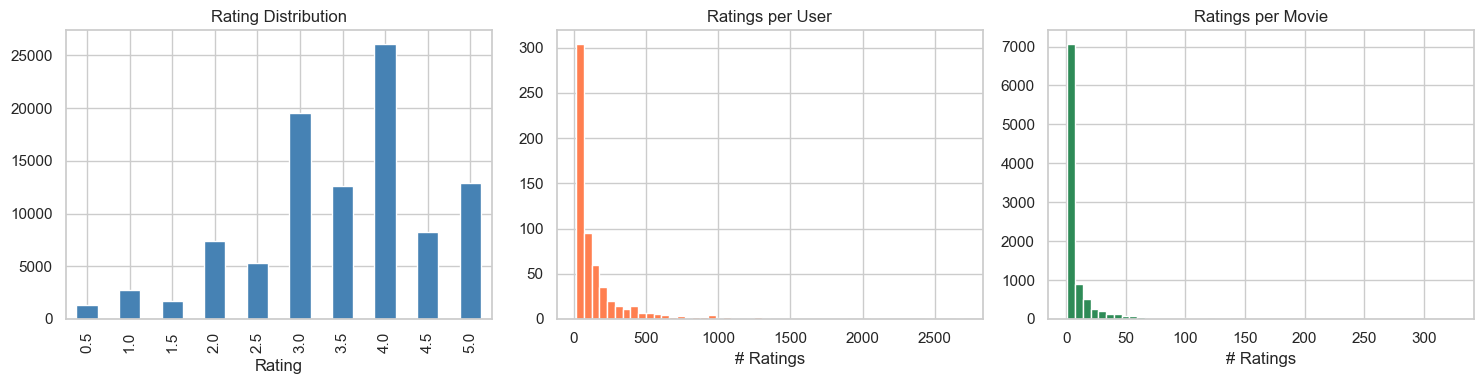

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ratings.rating.value_counts().sort_index().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')

ratings.groupby('userId').size().hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Ratings per User')
axes[1].set_xlabel('# Ratings')

ratings.groupby('movieId').size().hist(bins=50, ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Ratings per Movie')
axes[2].set_xlabel('# Ratings')

plt.tight_layout()
plt.show()

A few patterns can be seen from the plots and summary statistics.

First, the user-item matrix is extremely sparse, with about 98% of possible ratings missing. This already suggests that direct user-user overlap will often be limited.

Second, activity is very uneven. On average a user gives 163 ratings, but the median is only 69.5. This means a smaller group of active users contributes a large part of the data.

Third, the movie side is even more concentrated. The average movie has about 10 ratings, but the median is only 3, and almost 60% of all ratings come from the top 10% most-rated movies. This long-tail structure helps explain why popularity-based recommendations can look stronger than expected.

---

It is also checked whether all users in the test set are already present in the training data. This matters because collaborative filtering methods rely on past user interactions. If a test user has no history, a cold-start problem is faced and a fallback strategy is needed.

In [ ]:
train_user_ids = set(ratings.userId.unique())
test_user_ids = set(test_users.userId.tolist())

cold_start_users = test_user_ids - train_user_ids
warm_users = test_user_ids & train_user_ids
n_test_users = len(test_user_ids)

print(f'Test users in training data: {len(warm_users)} ({len(warm_users) / n_test_users:.0%})')
print(f'New users (cold-start):      {len(cold_start_users)} ({len(cold_start_users) / n_test_users:.0%})')
print(f'Coldstart user IDs:         {sorted(cold_start_users)}')

Test users in training data: 90 (90%)
New users (cold-start):      10 (10%)
Cold-start user IDs:         [31, 40, 219, 228, 245, 369, 381, 450, 480, 483]


## Train/Validation Split

For validation, a temporal split is used. For each user, the ratings are sorted by timestamp and the last few interactions are held out. The remaining interactions are used for training.

This split was chosen because the timestamps allow the order of interactions to be respected instead of using a fully random split. Since the assignment is about recommendation, it is more meaningful to ask whether the model can recover movies the user interacted with later in time.

For the ranking evaluation, only held-out items with a rating of 4.0 or higher are treated as relevant. This way, Precision@K and Recall@K reflect how well the model surfaces movies the user actually liked. The same idea is used in Task 2 as well: since 10% of the test users are cold-start users, the final pipeline needs a fallback and cannot rely on collaborative filtering alone.

This is not a perfect setup, but it gives a practical validation scheme.

In [8]:
HOLDOUT_N = 5
THRESHOLD = 4.0

ratings_sorted = ratings.sort_values(['userId', 'timestamp'])
val_indices = ratings_sorted.groupby('userId').tail(HOLDOUT_N).index
val_df = ratings_sorted.loc[val_indices].reset_index(drop=True)
train_df = ratings_sorted.drop(val_indices).reset_index(drop=True)

val_liked = val_df[val_df.rating >= THRESHOLD]
val_user_count = val_df.userId.nunique()
relevant_user_count = val_liked.userId.nunique()

print(f'Training ratings:      {len(train_df)}')
print(f'Validation ratings:    {len(val_df)} (last {HOLDOUT_N} per user)')
print(f'  of which relevant:   {len(val_liked)} (rating >= {THRESHOLD})')
print(f'  users with relevant: {relevant_user_count} ({relevant_user_count / val_user_count:.2%} of all users)')

Training ratings:      94801
Validation ratings:    3000 (last 5 per user)
  of which relevant:   1696 (rating >= 4.0)
  users with relevant: 533 (88.83% of all users)


In [9]:
reader = Reader(rating_scale=(0.5, 5.0))
trainset = Dataset.load_from_df(train_df[['userId', 'movieId', 'rating']], reader).build_full_trainset()

# RMSE is computed on all held-out items
val_tuples = list(zip(val_df.userId, val_df.movieId, val_df.rating))

# Ranking evaluation uses only the liked held-out items
ground_truth = val_liked.groupby('userId')['movieId'].apply(set).to_dict()

watched = train_df.groupby('userId')['movieId'].apply(set).to_dict()
all_movie_ids = set(train_df.movieId.unique()) | set(val_df.movieId.unique())

print(f'Trainset: {trainset.n_users} users, {trainset.n_items} items')

Trainset: 600 users, 9571 items


## Evaluation

The models are evaluated from two angles.

**Rating prediction:** RMSE is used to measure how accurately the models predict ratings.

**Recommendation quality:** Since the assignment asks for Precision@K and Recall@K, these are reported as the main ranking metrics. HR@10 and NDCG@10 are also included as additional indicators.

The definitions of relevant items, top-$K$ lists, and precision/recall follow the same spirit as in the [Surprise FAQ](https://surprise.readthedocs.io/en/stable/FAQ.html) (sections on top-$N$ recommendations and precision/recall at $K$). Here I use a temporal holdout plus random negatives instead of a full test set, so the code is not a copy of that example, but the metric meaning is aligned.

For the ranking evaluation, a sampled setting is used: for each user, the held-out relevant items are ranked together with a set of randomly sampled unseen movies. This keeps the computation manageable while still allowing the ranking behaviour of different models to be compared.

One limitation of this setup is that each user only contributes a small number of held-out relevant items, so the ranking metrics should be interpreted with some care.

In [10]:
N_NEGATIVES = 499
K = 10

np.random.seed(42)
eval_samples = {}
for user_id, pos_movies in ground_truth.items():
    user_watched = watched.get(user_id, set())
    negative_pool = list(all_movie_ids - user_watched - pos_movies)
    n_neg = min(N_NEGATIVES, len(negative_pool))
    negatives = list(np.random.choice(negative_pool, size=n_neg, replace=False))
    eval_samples[user_id] = (list(pos_movies), negatives)

avg_relevant = np.mean([len(pm) for pm, _ in eval_samples.values()])
print(f'Evaluation users:          {len(eval_samples)}')
print(f'Avg relevant items/user:   {avg_relevant:.1f}')
print(f'Negatives per user:        {N_NEGATIVES}')

Evaluation users:          533
Avg relevant items/user:   3.2
Negatives per user:        499


In [11]:
def evaluate(model, name):
    """Evaluate a model on RMSE and ranking metrics."""
    start = time.time()
    
    preds = [model.predict(u, m, r) for u, m, r in val_tuples]
    rmse = accuracy.rmse(preds, verbose=False)
    
    precisions, recalls, hrs, ndcgs = [], [], [], []
    
    for user_id, (pos_movies, negatives) in eval_samples.items():
        candidates = pos_movies + negatives
        scores = [(mid, model.predict(user_id, mid).est) for mid in candidates]
        scores.sort(key=lambda x: x[1], reverse=True)
        top_k = [mid for mid, _ in scores[:K]]
        
        pos_set = set(pos_movies)
        n_relevant = len(pos_movies)
        n_hits = sum(1 for m in top_k if m in pos_set)
        
        precisions.append(n_hits / K)
        recalls.append(n_hits / n_relevant if n_relevant > 0 else 0)
        hrs.append(1 if n_hits > 0 else 0)
        
        dcg = sum(1.0 / np.log2(i + 2) for i, mid in enumerate(top_k) if mid in pos_set)
        ideal = sum(1.0 / np.log2(i + 2) for i in range(min(n_relevant, K)))
        ndcgs.append(dcg / ideal if ideal > 0 else 0)
    
    elapsed = time.time() - start
    
    result = {
        'Model': name,
        'RMSE': round(rmse, 4),
        f'P@{K}': round(np.mean(precisions), 4),
        f'R@{K}': round(np.mean(recalls), 4),
        f'HR@{K}': round(np.mean(hrs), 4),
        f'NDCG@{K}': round(np.mean(ndcgs), 4),
        'Time (s)': round(elapsed, 1)
    }
    
    print(f'{name:30s} | RMSE={rmse:.4f} | P@{K}={np.mean(precisions):.4f} | R@{K}={np.mean(recalls):.4f} | NDCG@{K}={np.mean(ndcgs):.4f} | {elapsed:.1f}s')
    return result

## Task 1: Building and Evaluating Models

Three models are compared.

1. **Baseline model** — This model captures global effects such as the overall average rating and per-user / per-item biases. It serves as a useful reference point.

2. **User-based collaborative filtering** — This model recommends movies based on the preferences of similar users. It is intuitive and easy to explain, but it can struggle when the overlap between users is limited.

3. **SVD (matrix factorization)** — This model learns lower-dimensional latent representations of users and movies. It is often better suited for sparse datasets, where direct user-user overlap is weak.

In [12]:
results = []

baseline_model = BaselineOnly(bsl_options={'method': 'als', 'n_epochs': 10})
baseline_model.fit(trainset)
results.append(evaluate(baseline_model, 'Baseline (mean+biases)'))

Estimating biases using als...


Baseline (mean+biases)         | RMSE=0.9389 | P@10=0.0756 | R@10=0.2255 | NDCG@10=0.1761 | 0.3s


In [13]:
userbased_model = KNNBaseline(
    k=40,
    min_k=3,
    sim_options={'name': 'pearson_baseline', 'user_based': True},
    verbose=False
)
userbased_model.fit(trainset)
results.append(evaluate(userbased_model, 'User-Based CF (KNNBaseline)'))

User-Based CF (KNNBaseline)    | RMSE=0.9398 | P@10=0.0370 | R@10=0.1137 | NDCG@10=0.0711 | 1.7s


In [14]:
svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)
svd_model.fit(trainset)
results.append(evaluate(svd_model, 'SVD'))

SVD                            | RMSE=0.9366 | P@10=0.0638 | R@10=0.1894 | NDCG@10=0.1424 | 0.4s


In [15]:
results_df = pd.DataFrame(results)
results_df

,Model,RMSE,P@10,R@10,HR@10,NDCG@10,Time (s)
0,Baseline (mean+biases),0.9389,0.0756,0.2255,0.4503,0.1761,0.3
1,User-Based CF (KNNBaseline),0.9398,0.0370,0.1137,0.2927,0.0711,1.7
2,SVD,0.9366,0.0638,0.1894,0.4071,0.1424,0.4


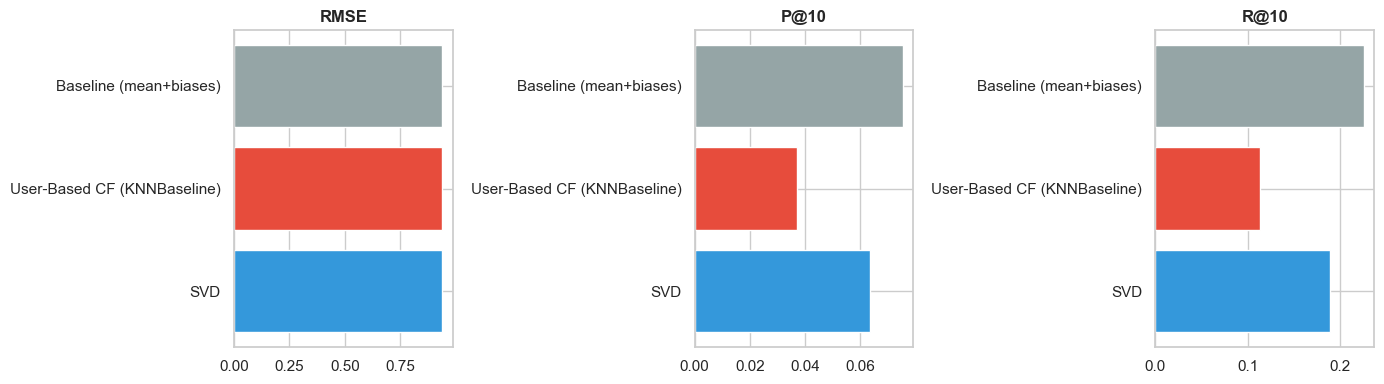

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, metric in enumerate(['RMSE', f'P@{K}', f'R@{K}']):
    ax = axes[i]
    ax.barh(results_df['Model'], results_df[metric], color=['#95a5a6', '#e74c3c', '#3498db'])
    ax.set_title(metric, fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

To also assess how personalized the recommendations are, a few simple recommendation-level statistics are compared. Besides catalog coverage, I also check how popular the recommended movies are on average and how often the same movie is repeated across users' top-10 lists. This gives a more direct picture of the popularity-personalization trade-off than adding extra metrics that are not required by the assignment.

In [17]:
# Compare coverage and popularity patterns in top-10 lists across a sample of users
sample_uids = sorted(ground_truth.keys())[:50]
movie_popularity = train_df.groupby('movieId').size().to_dict()

print(f'Recommendation statistics for top-{K} lists over {len(sample_uids)} sampled users:')
print()

for model, name in [(baseline_model, 'Baseline'), (userbased_model, 'User-Based CF'), (svd_model, 'SVD')]:
    unique_recs = set()
    repeat_counts = {}
    popularity_counts = []

    for uid in sample_uids:
        user_seen = watched.get(uid, set())
        unseen = list(all_movie_ids - user_seen)
        scores = [(mid, model.predict(uid, mid).est) for mid in unseen]
        scores.sort(key=lambda x: x[1], reverse=True)
        top_k = [mid for mid, _ in scores[:K]]

        unique_recs.update(top_k)
        popularity_counts.extend(movie_popularity.get(mid, 0) for mid in top_k)

        for mid in top_k:
            repeat_counts[mid] = repeat_counts.get(mid, 0) + 1

    print(
        f'  {name:30s}: '
        f'coverage={len(unique_recs):>4} unique movies | '
        f'avg popularity={np.mean(popularity_counts):>6.1f} ratings | '
        f'max repeat={max(repeat_counts.values()):>2} users'
    )

Recommendation statistics for top-10 lists over 50 sampled users:



  Baseline                      : coverage=  43 unique movies | avg popularity= 129.4 ratings | max repeat=46 users


  User-Based CF                 : coverage= 252 unique movies | avg popularity=  14.1 ratings | max repeat=15 users


  SVD                           : coverage= 160 unique movies | avg popularity=  88.1 ratings | max repeat=17 users


### Discussion

The three models highlight different trade-offs.

The bias-based baseline performs surprisingly well on the validation set, especially on Recall@10. Given the data statistics above, this is not too surprising: almost 60% of all ratings come from the top 10% most-rated movies, so a model that strongly reflects global popularity can recover many relevant items. At the same time, the recommendation statistics show its limitation very clearly. Across 50 sampled users, it only covers 43 unique movies, its average recommended movie is very popular, and a single movie appears in 46 users' top-10 lists. So the baseline is useful as a reference, but it is weak in personalization.

The user-based CF model is easy to explain, since each prediction comes from similar users. However, its ranking performance is the weakest of the three models. That result is consistent with the data: the matrix is about 98% sparse and the median movie has only 3 ratings, so user-user overlap is often too small for stable neighborhoods.

SVD gives the best RMSE and clearly better ranking performance than the user-based model. It also covers 160 unique movies across the sampled users, which is much broader than the baseline while still keeping the recommendations more focused than the user-based model. In this notebook, that makes SVD the most balanced choice between accuracy and personalization.

Because the assignment is about recommending movies to individual users, I use SVD as the final personalized model. The baseline remains helpful as a benchmark, but its lists are too concentrated around the same popular titles.

### Hyperparameter Tuning

A small hyperparameter search is also run for SVD to check whether a better configuration can be found. The search space is kept small, since the main objective is to compare reasonable model choices rather than to maximize performance at all costs.

In [18]:
param_grid = {
    'n_factors': [50, 100],
    'n_epochs': [20, 30],
    'lr_all': [0.005, 0.01],
    'reg_all': [0.02, 0.1],
}

surprise_data = Dataset.load_from_df(train_df[['userId', 'movieId', 'rating']], reader)
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
gs.fit(surprise_data)

print(f'Best RMSE (CV): {gs.best_score["rmse"]:.4f}')
print(f'Best params:    {gs.best_params["rmse"]}')

# Quick check on temporal validation
svd_tuned = SVD(**gs.best_params['rmse'], random_state=42)
svd_tuned.fit(trainset)
tuned_result = evaluate(svd_tuned, 'SVD (tuned)')

Best RMSE (CV): 0.8643
Best params:    {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


SVD (tuned)                    | RMSE=0.9161 | P@10=0.0385 | R@10=0.1100 | NDCG@10=0.0779 | 0.4s


The tuned version improved cross-validation RMSE, but it did not improve Precision@10 or Recall@10 on the temporal validation split. Since the grid search optimized only RMSE on random folds, this mismatch is reasonable. For that reason, I kept the simpler default SVD configuration for the final recommendation step instead of adding more tuning complexity.

## Task 2: Generating Recommendations

For the final recommendation step, I use SVD as the main personalized model. Although the baseline performed well on some validation metrics, it mostly captures global popularity and gives much less personalized recommendation lists. Since the purpose of this task is to recommend movies to individual users, SVD is a more suitable final model.

The final recommendation strategy depends on whether the user already appears in the training data.

- For **warm users**, I predict scores for all unseen movies and return the top 10.
- For **cold-start users**, collaborative filtering cannot use past behaviour, so I fall back to a popularity-based recommendation list.

This distinction matters in this dataset because 10 out of the 100 test users are cold-start users. For the cold-start case, I use a weighted rating instead of a plain average. This avoids giving too much importance to movies that only received a very small number of ratings.

This approach is simple, but it fits the structure of the dataset and handles both seen and unseen users in a practical way.

In [19]:
# Retrain the final model on the full training data
full_trainset = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']], reader
).build_full_trainset()

final_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)
final_model.fit(full_trainset)

# Keep track of which movies each user has already rated
user_watched_all = ratings.groupby('userId')['movieId'].apply(set).to_dict()
all_movies = set(ratings.movieId.unique())

print('Final SVD model trained on the full training set.')

Final SVD model trained on the full training set.


In [20]:
# Popularity-based fallback for cold-start users
# A weighted score is used so that movies with very few ratings do not rank too high
global_mean = ratings.rating.mean()
min_votes = movies.num_ratings.quantile(0.75)

popular = movies[movies.num_ratings >= min_votes].copy()
popular['score'] = (
    (popular.num_ratings / (popular.num_ratings + min_votes)) * popular.avg_rating +
    (min_votes / (popular.num_ratings + min_votes)) * global_mean
)

fallback_top10 = popular.nlargest(10, 'score').movieId.tolist()

print('Top 10 fallback movies for cold-start users:')
for mid in fallback_top10:
    title = movies[movies.movieId == mid].title.values[0]
    print(f'  {mid}: {title}')

Top 10 fallback movies for cold-start users:
  318: Shawshank Redemption, The (1994)
  858: Godfather, The (1972)
  2959: Fight Club (1999)
  1213: Goodfellas (1990)
  1221: Godfather: Part II, The (1974)
  750: Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)
  1208: Apocalypse Now (1979)
  50: Usual Suspects, The (1995)
  260: Star Wars: Episode IV - A New Hope (1977)
  1104: Streetcar Named Desire, A (1951)


In [21]:
# Generate recommendations for every user in the test set
recommendations = {}

for user_id in test_users.userId:
    if user_id in cold_start_users:
        # No training history is available, so use the fallback list
        recommendations[user_id] = fallback_top10
    else:
        # Score all unseen movies and keep the top 10
        seen = user_watched_all.get(user_id, set())
        unseen = all_movies - seen

        predictions = [(mid, final_model.predict(user_id, mid).est) for mid in unseen]
        predictions.sort(key=lambda x: x[1], reverse=True)

        recommendations[user_id] = [mid for mid, _ in predictions[:10]]

# Basic sanity check
for uid, recs in recommendations.items():
    assert len(recs) == 10
    assert len(set(recs)) == 10

print(f'Generated recommendations for {len(recommendations)} test users.')
print(f'  Warm users: {len(warm_users)}')
print(f'  Cold-start users: {len(cold_start_users)}')

Generated recommendations for 100 test users.
  Warm users: 90
  Cold-start users: 10


To make the output a bit easier to inspect, I also print one example for a warm user and one for a cold-start user. This is only a qualitative check, but it helps confirm that the pipeline behaves as expected: warm users receive personalized recommendations, while cold-start users receive the same fallback list.

In [22]:
movie_titles = dict(zip(movies.movieId, movies.title))

example_warm = sorted(warm_users)[0]
example_cold = sorted(cold_start_users)[0]

for uid, label in [(example_warm, 'warm'), (example_cold, 'cold-start')]:
    print(f'\nUser {uid} ({label}):')
    for i, mid in enumerate(recommendations[uid], 1):
        print(f'  {i}. {movie_titles.get(mid, "?")}')


User 3 (warm):
  1. Groundhog Day (1993)
  2. Goodfellas (1990)
  3. Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
  4. Mr. Holland's Opus (1995)
  5. K-PAX (2001)
  6. Finding Nemo (2003)
  7. Hoop Dreams (1994)
  8. Last Detail, The (1973)
  9. Dark Knight, The (2008)
  10. Gaslight (1944)

User 31 (cold-start):
  1. Shawshank Redemption, The (1994)
  2. Godfather, The (1972)
  3. Fight Club (1999)
  4. Goodfellas (1990)
  5. Godfather: Part II, The (1974)
  6. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)
  7. Apocalypse Now (1979)
  8. Usual Suspects, The (1995)
  9. Star Wars: Episode IV - A New Hope (1977)
  10. Streetcar Named Desire, A (1951)


In [23]:
output = test_users.copy()
rec_columns = [f'recommendation{i}' for i in range(1, 11)]

for idx, row in output.iterrows():
    recs = recommendations[row['userId']]
    for j, col in enumerate(rec_columns):
        output.at[idx, col] = int(recs[j])

for col in rec_columns:
    output[col] = output[col].astype(int)

output.to_csv(DATA_DIR / 'ratings_test.csv', index=False)

check = pd.read_csv(DATA_DIR / 'ratings_test.csv')
print(f'Saved ratings_test.csv — {check.shape}')
print(f'Empty cells: {check.isnull().sum().sum()}')
check.head()

Saved ratings_test.csv — (100, 11)
Empty cells: 0


,userId,recommendation1,recommendation2,recommendation3,recommendation4,recommendation5,recommendation6,recommendation7,recommendation8,recommendation9,recommendation10
0,3,1265,1213,32,62,4874,6377,246,3200,58559,906
1,7,858,1221,926,1203,1198,78499,112552,908,527,318
2,11,2571,260,1204,1198,1136,1213,899,858,912,750
3,25,50,296,318,356,608,750,858,898,908,912
4,30,50,750,858,1197,1225,1258,2329,2959,3147,3435


## Conclusion

The final recommendation step reflects one practical limitation of collaborative filtering: it works best when some interaction history is available. For users already present in the training data, SVD can generate user-specific rankings. For unseen users, however, there is not enough information to personalize the recommendations, so a popularity-based fallback is a reasonable solution.

Overall, the dataset is difficult for recommendation because it is about 98% sparse and strongly long-tail. A simple baseline can therefore look strong on some ranking metrics, but the recommendation statistics show that it tends to repeat the same popular titles. The user-based model is more interpretable, but it suffers from weak overlap between users.

SVD gives the best balance in this notebook. It keeps the strongest RMSE, better ranking performance than the user-based method, and much broader recommendation coverage than the baseline. This is not a perfect solution to the cold-start problem, but it is simple, transparent, and appropriate for the scope of this assignment.

**Future work:** A natural extension would be a hybrid model such as [LightFM](https://making.lyst.com/lightfm/docs/home.html), which can combine collaborative signals with item side information (for example genres from `movies.csv`). The library also documents ranking metrics like precision at $k$, but its tutorials often focus on implicit feedback, while this assignment uses explicit ratings and RMSE, so I kept the main pipeline to Surprise for clarity.